# Loading dependencies

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from tqdm import trange

# Loading cube

10, 1536, 1536, 35 = shape of the data

10 - physical parameters (T, p, B(x,y,z), v(x,y,z), tau, z_axis)\
1536 x 1536 - field \
35 - z layers 

In [2]:
fits_path = '/kaggle/input/datasets/siladavid/muram-iso-z-second-batch/muram_3D_cutout1800.fits'
data_raw = fits.open(fits_path)

print("Broj HDU:", len(data_raw))
print("Shape:", data_raw[0].data.shape)

Broj HDU: 10
Shape: (1536, 1536, 35)


In [3]:
SUB = 128 # taking the sub domen of the cube 1536x1536 -> 128x128

T = data_raw[0].data[:SUB, :SUB, :]
p = data_raw[1].data[:SUB, :SUB, :]
Bx = data_raw[2].data[:SUB, :SUB, :]
By = data_raw[3].data[:SUB, :SUB, :]
Bz = data_raw[4].data[:SUB, :SUB, :]
vx = data_raw[5].data[:SUB, :SUB, :]
vy = data_raw[6].data[:SUB, :SUB, :]
vz = data_raw[7].data[:SUB, :SUB, :]
tau = data_raw[8].data[:SUB, :SUB, :]

z_axis = data_raw[9].data

In [4]:
print("T shape:", T.shape) # (Nx, Ny, Nz)
print("z_axis shape:", z_axis.shape)
print("z_axis range:", z_axis.min(), z_axis.max())

fields = [T, p, Bx, By, Bz, vx, vy, vz]

field_names = ['T', 'p', 'Bx', 'By', 'Bz', 'vx', 'vy', 'vz']

for name, f in zip(field_names, fields):
    print(f"{name}: shape={f.shape}, min={f.min():.3e}, max={f.max():.3e}")

T shape: (128, 128, 35)
z_axis shape: (35,)
z_axis range: -160.0 384.0
T: shape=(128, 128, 35), min=3.590e+03, max=1.131e+04
p: shape=(128, 128, 35), min=2.339e+02, max=2.617e+05
Bx: shape=(128, 128, 35), min=-9.316e+02, max=9.772e+02
By: shape=(128, 128, 35), min=-1.248e+03, max=7.246e+02
Bz: shape=(128, 128, 35), min=-1.641e+03, max=1.930e+03
vx: shape=(128, 128, 35), min=-7.275e+05, max=1.045e+06
vy: shape=(128, 128, 35), min=-7.320e+05, max=1.224e+06
vz: shape=(128, 128, 35), min=-1.040e+06, max=7.874e+05


# Normalizing x,y,z

In [5]:
Nx, Ny, Nz = T.shape

x_coords = np.linspace(0, 1, Nx)
y_coords = np.linspace(0, 1, Ny)
z_coords = np.linspace(0, 1, Nz)

xx, yy, zz = np.meshgrid(x_coords, y_coords, z_coords, indexing='ij')

coords = np.stack([xx.ravel(), yy.ravel(), zz.ravel()], axis=1).astype(np.float32)
print("coords shape:", coords.shape)

coords shape: (573440, 3)


# Normalizing targets

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device we are using:", device)

targets_raw = np.stack([f.ravel() for f in fields], axis=1).astype(np.float32) # ravel 3D -> 1D

print('Targets shape:', targets_raw.shape)

field_mins   = targets_raw.min(axis=0)
field_maxs   = targets_raw.max(axis=0)
targets_norm = (targets_raw - field_mins) / (field_maxs - field_mins + 1e-10)

X_train = torch.from_numpy(coords).to(device)
Y_train = torch.from_numpy(targets_norm).to(device)
print("Training on:", X_train.shape[0])

Device we are using: cuda
Targets shape: (573440, 8)
Training on: 573440


In [7]:
n_total = coords.shape[0]
print('Total points', n_total)
idx = np.random.choice(n_total, size=200000, replace=False)

X_train = torch.from_numpy(coords[idx]).to(device)
Y_train = torch.from_numpy(targets_norm[idx]).to(device)

print("Training points:", X_train.shape[0])

Total points 573440
Training points: 200000


# Defining neural network structure

In [8]:
class NeuralField(nn.Module):
    
    def __init__(self, hidden_sizes=[256, 256, 256, 256, 256]):
        super().__init__()
        layers = []
        sizes = [3] + hidden_sizes + [8]
        for i in range(len(sizes) - 1):
            
            layers.append(nn.Linear(sizes[i], sizes[i+1]))
            
            if i < len(sizes) - 2:
                layers.append(nn.GELU())
                
        self.net = nn.Sequential(*layers)
        
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

In [9]:
import gc
torch.cuda.empty_cache()
gc.collect()

model = NeuralField(hidden_sizes=[256, 256, 256, 256, 256]).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"No. of network parameters: {n_params:,}")
print(f"Compression: {targets_raw.nbytes/(n_params*4):.1f}x")

No. of network parameters: 266,248
Compression: 17.2x


In [10]:
# model = NeuralField(hidden_sizes=[80, 80, 80, 80]).to(device)

# n_params = sum(p.numel() for p in model.parameters())
# print(f"Parameters: {n_params:,}")
# print(f"Compression: {targets_raw.nbytes/(n_params*4):.1f}x")

In [11]:
batch_size        = 65536
n_train           = X_train.shape[0]
BATCHES_PER_EPOCH = 40   
history_loss      = []
epochs = 4000

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# Training loop

In [12]:
for epoch in trange(epochs):
    epoch_loss = 0.0
    for _ in range(BATCHES_PER_EPOCH):
        idx     = torch.randint(0, n_train, (batch_size,), device=device)
        X_batch = X_train[idx]
        Y_batch = Y_train[idx]

        optimizer.zero_grad()
        loss = nn.functional.mse_loss(model(X_batch), Y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / BATCHES_PER_EPOCH
    history_loss.append(avg_loss)

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | Loss: {avg_loss:.4e} | LR: {scheduler.get_last_lr()[0]:.2e}")

  0%|          | 1/4000 [00:01<2:07:15,  1.91s/it]

Epoch 0 | Loss: 4.9192e-02 | LR: 1.00e-03


  5%|▌         | 201/4000 [05:28<1:45:16,  1.66s/it]

Epoch 200 | Loss: 1.1624e-03 | LR: 9.94e-04


 10%|█         | 401/4000 [11:03<1:40:47,  1.68s/it]

...

 90%|█████████ | 3601/4000 [1:39:36<11:00,  1.65s/it]

Epoch 3600 | Loss: 1.3808e-04 | LR: 2.44e-05


 95%|█████████▌| 3801/4000 [1:45:05<05:29,  1.65s/it]

Epoch 3800 | Loss: 1.3696e-04 | LR: 6.09e-06


100%|██████████| 4000/4000 [1:50:35<00:00,  1.66s/it]


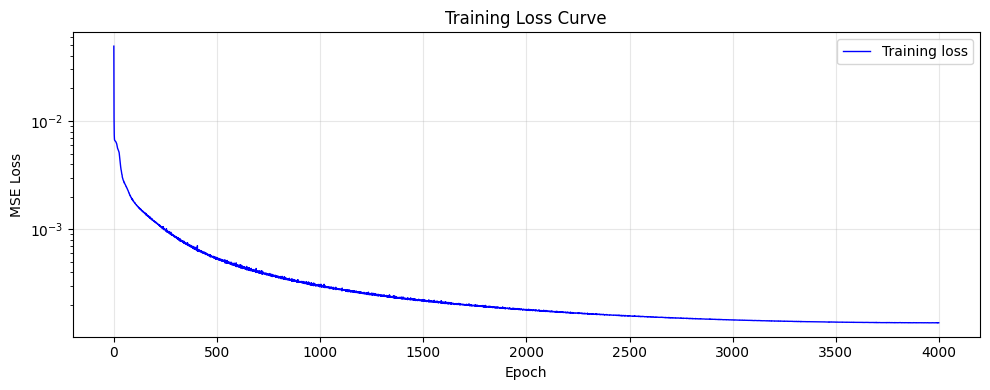

Start loss : 4.9192e-02
Final loss : 1.3683e-04


In [13]:
plt.figure(figsize=(10, 4))

# Loss curve
plt.plot(history_loss, 'b-', linewidth=1, label='Training loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Curve')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Start loss : {history_loss[0]:.4e}")
print(f"Final loss : {history_loss[-1]:.4e}")

# Calling the model

In [14]:
# Full grid coordinates
X_full = torch.from_numpy(coords).to(device)

model.eval()
chunk = 200_000
preds = []

with torch.no_grad():
    for s in range(0, X_full.shape[0], chunk):
        preds.append(model(X_full[s:s+chunk]).cpu().numpy())

pred_norm = np.concatenate(preds, axis=0)
print("pred_norm shape:", pred_norm.shape)  # should be (2293760, 8)

# Denormalization
pred_raw = pred_norm * (field_maxs - field_mins) + field_mins
pred_raw = pred_raw.reshape(Nx, Ny, Nz, 8)
true_raw = targets_raw.reshape(Nx, Ny, Nz, 8)

pred_norm shape: (573440, 8)


# Ploting the results

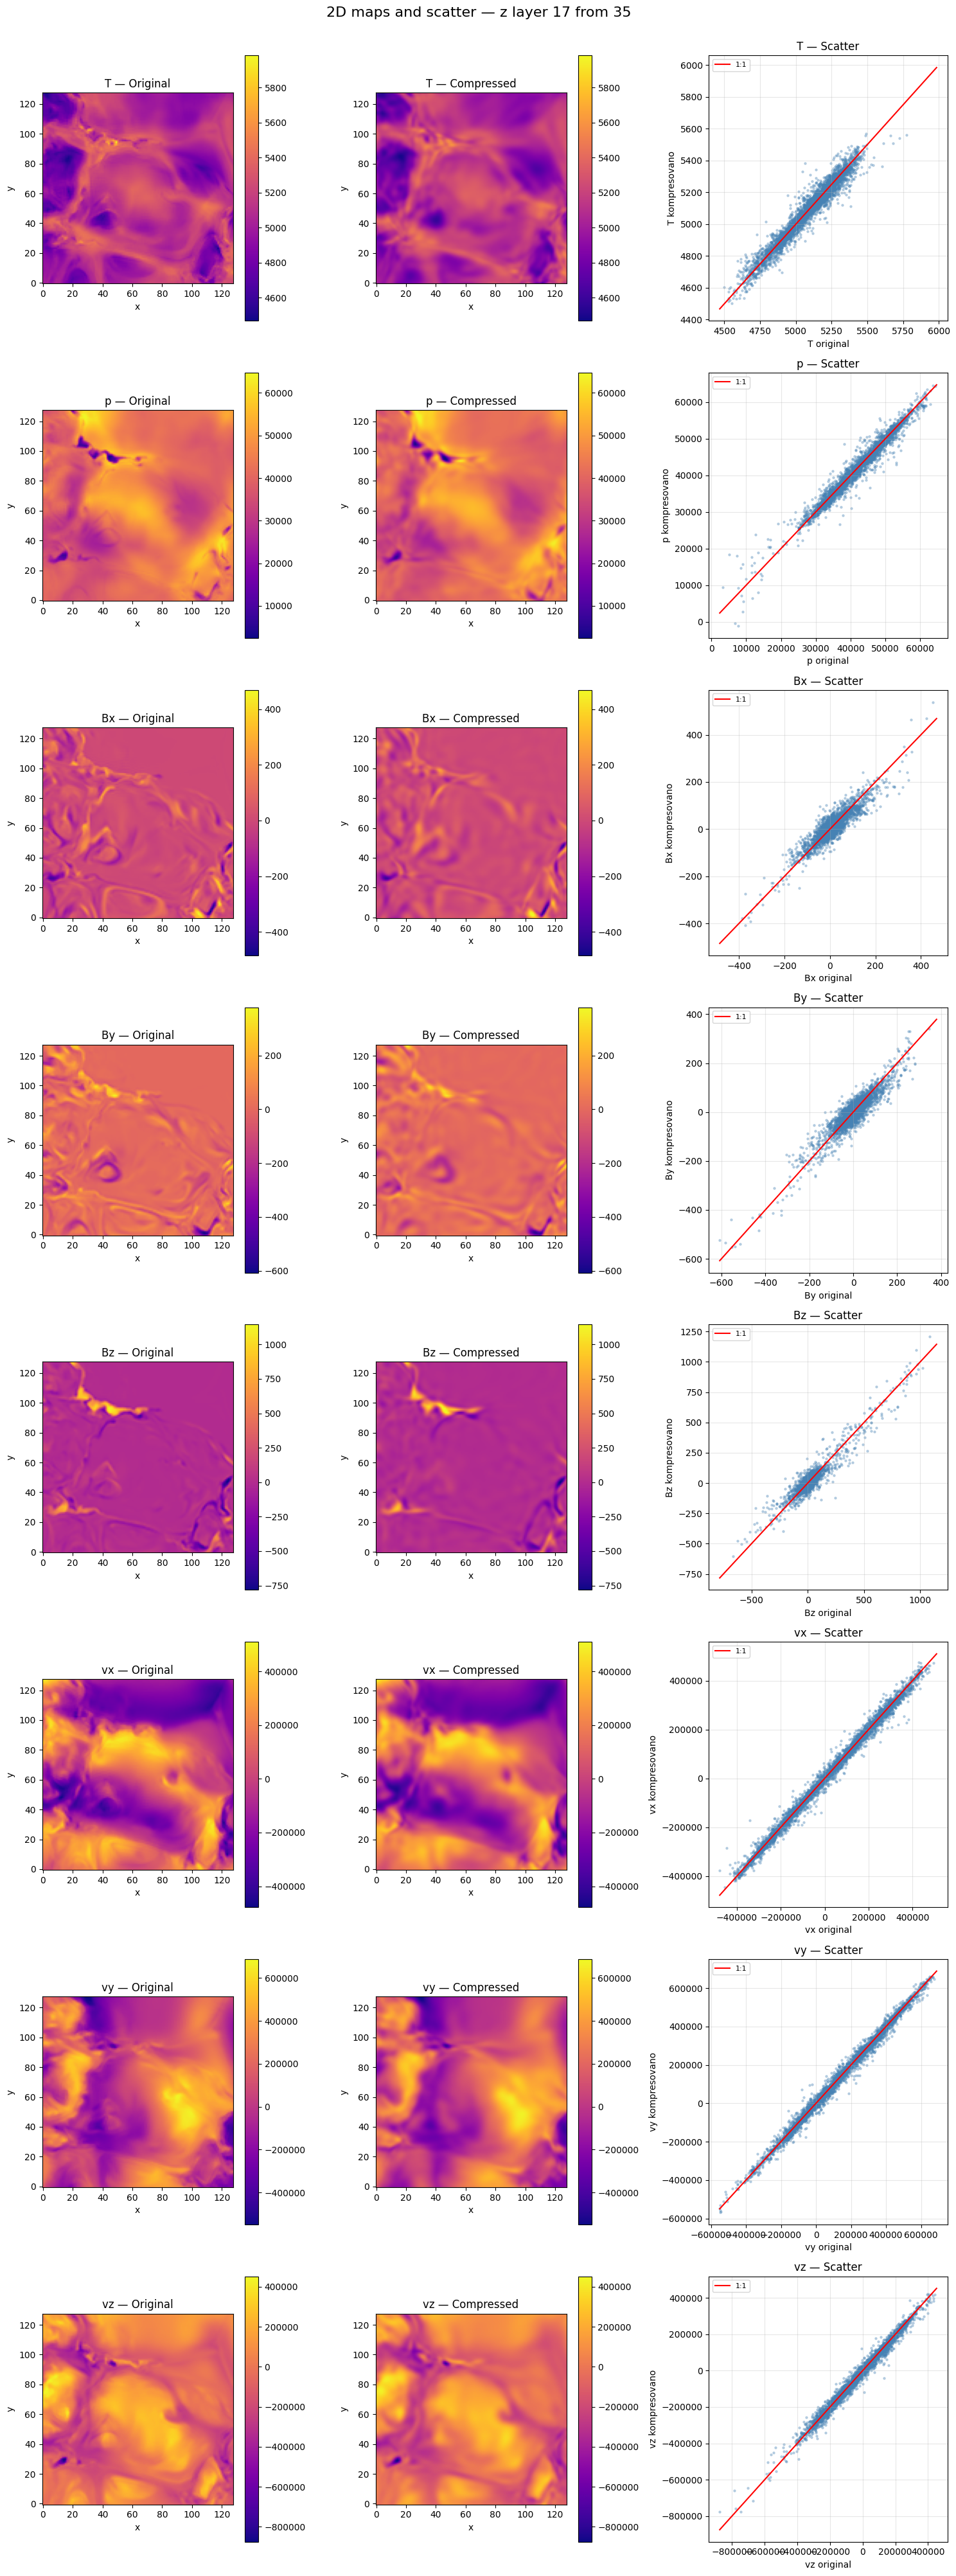

In [15]:
iz = Nz // 2  # middle z layer

fig, axes = plt.subplots(8, 3, figsize=(15, 40))

for i, name in enumerate(field_names):
    
    # 2D maps on middle z
    
    f_true = true_raw[:, :, iz, i]   # (Nx, Ny)
    f_pred = pred_raw[:, :, iz, i]   # (Nx, Ny)

    vmin = f_true.min()
    vmax = f_true.max()

    # --- Plot 1: Truth ---
    ax = axes[i, 0]
    im = ax.imshow(f_true, origin='lower', vmin=vmin, vmax=vmax, cmap='plasma')
    ax.set_title(f'{name} — Original')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    plt.colorbar(im, ax=ax)

    # --- Plot 2: Pred ---
    ax = axes[i, 1]
    im = ax.imshow(f_pred, origin='lower', vmin=vmin, vmax=vmax, cmap='plasma')
    ax.set_title(f'{name} — Compressed')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    plt.colorbar(im, ax=ax)

    # --- Plot 3: Scatter 1:1 ---
    ax = axes[i, 2]
    
    # Subsample for scatter plot
    idx = np.random.choice(f_true.size, size=5000, replace=False)
    ax.scatter(f_true.ravel()[idx], f_pred.ravel()[idx],
               alpha=0.3, s=5, color='steelblue')
    # Linija 1:1
    ax.plot([vmin, vmax], [vmin, vmax], 'r-', linewidth=1.5, label='1:1')
    ax.set_xlabel(f'{name} original')
    ax.set_ylabel(f'{name} kompresovano')
    ax.set_title(f'{name} — Scatter')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f'2D maps and scatter — z layer {iz} from {Nz}', fontsize=16, y=1.001)
plt.tight_layout()
plt.show()

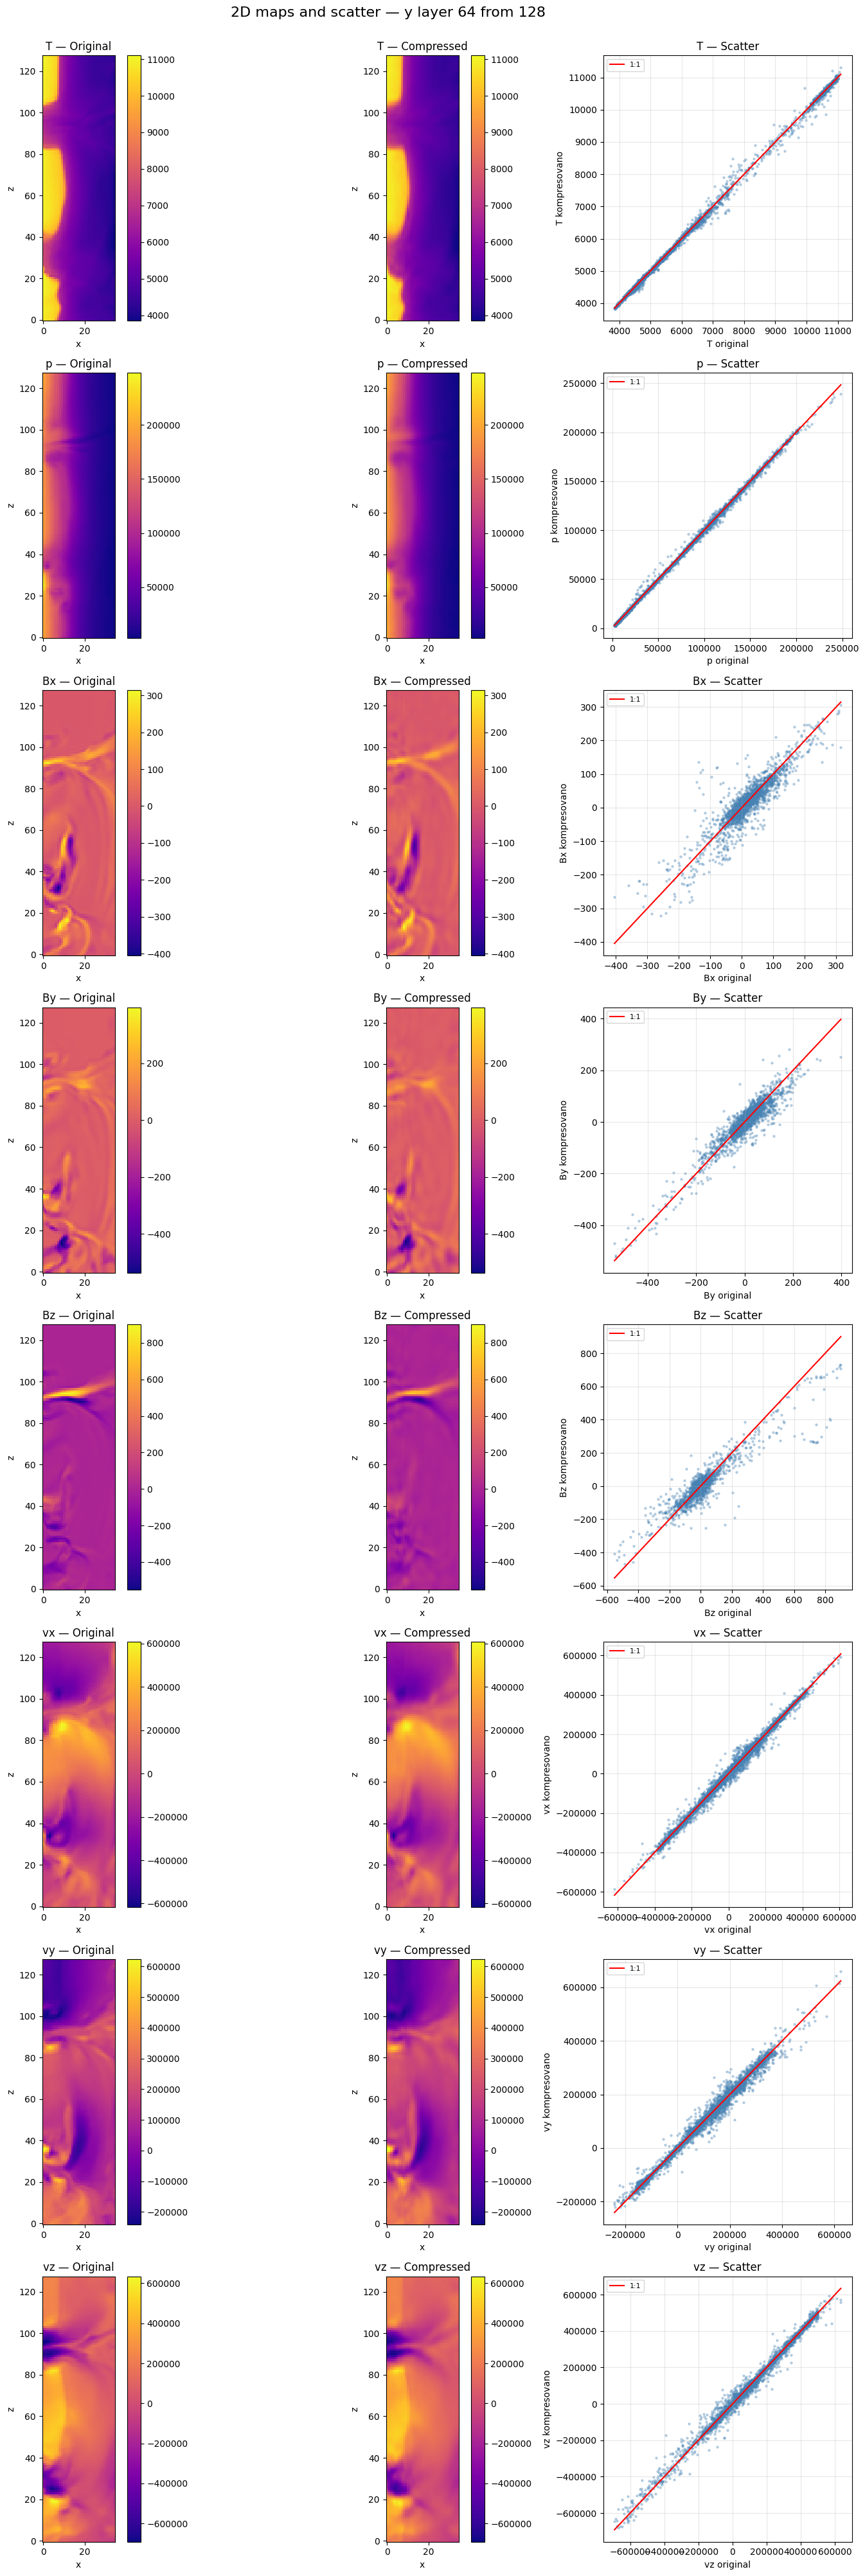

In [16]:
iy = Ny // 2
fig, axes = plt.subplots(8, 3, figsize=(15, 40))

for i, name in enumerate(field_names):
    
    # 2D maps on middle y
    
    f_true = true_raw[:, iy, :, i]   # (Nx, Nz)
    f_pred = pred_raw[:, iy, :, i]   # (Nx, Nz)

    vmin = f_true.min()
    vmax = f_true.max()

    # --- Plot 1: Truth ---
    ax = axes[i, 0]
    im = ax.imshow(f_true, origin='lower', vmin=vmin, vmax=vmax, cmap='plasma')
    ax.set_title(f'{name} — Original')
    ax.set_xlabel('x'); ax.set_ylabel('z')
    plt.colorbar(im, ax=ax)

    # --- Plot 2: Pred ---
    ax = axes[i, 1]
    im = ax.imshow(f_pred, origin='lower', vmin=vmin, vmax=vmax, cmap='plasma')
    ax.set_title(f'{name} — Compressed')
    ax.set_xlabel('x'); ax.set_ylabel('z')
    plt.colorbar(im, ax=ax)

    # --- Plot 3: Scatter 1:1 ---
    ax = axes[i, 2]
    
    # Subsample for scatter plot
    n_samples = min(5000, f_true.size)
    idx = np.random.choice(f_true.size, size=n_samples, replace=False)
    ax.scatter(f_true.ravel()[idx], f_pred.ravel()[idx],
               alpha=0.3, s=5, color='steelblue')
    # Linija 1:1
    ax.plot([vmin, vmax], [vmin, vmax], 'r-', linewidth=1.5, label='1:1')
    ax.set_xlabel(f'{name} original')
    ax.set_ylabel(f'{name} kompresovano')
    ax.set_title(f'{name} — Scatter')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f'2D maps and scatter — y layer {iy} from {Ny}', fontsize=16, y=1.001)
plt.tight_layout()
plt.show()

In [17]:
# RMSE per field
for i, name in enumerate(field_names):
    rmse = np.sqrt(np.mean((pred_raw[..., i] - true_raw[..., i])**2))
    rel  = rmse / (true_raw[..., i].max() - true_raw[..., i].min()) * 100
    print(f"{name}: RMSE={rmse:.3e}, rel={rel:.2f}%")

T: RMSE=8.975e+01, rel=1.16%
p: RMSE=2.235e+03, rel=0.85%
Bx: RMSE=2.910e+01, rel=1.52%
By: RMSE=2.967e+01, rel=1.50%
Bz: RMSE=4.388e+01, rel=1.23%
vx: RMSE=2.343e+04, rel=1.32%
vy: RMSE=2.443e+04, rel=1.25%
vz: RMSE=2.591e+04, rel=1.42%
